<div align="center">
    
## <font color = #4854E8>**Diabetic Retinopathy Classification Using RetinalNet Custom CNN**</font>
<div>

**Student Name:** Chooladeva Kalukottege 

**RGU Index Number:** 2515364

**IIT Index Number:** 20250005

This notebook focuses on developing a deep learning model to classify diabetic retinopathy severity using a dataset of 35,126 retinal images. Each image is associated with a severity grade ranging from healthy to advanced disease, making it a multi-class classification problem with strong clinical relevance. The workflow covers the full pipeline, starting from data preprocessing and handling class imbalance, to training an RetinalNet Custom-based CNN model and evaluating its performance using metrics suited for ordinal classification. In addition to standard evaluation, the notebook also explores model behaviour through confusion matrices, ROC and precision-recall curves, calibration analysis, and Grad-CAM visualizations. The aim is not only to achieve good predictive performance but also to understand the strengths, limitations, and real-world applicability of the model in detecting and grading diabetic retinopathy.

---

### </font> <font color = #41EA46> **1: Import Libraries**</font>

In [2]:
# Import Libraries
import os, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as torch_F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
import torchvision.transforms.functional as F
from PIL import Image
from tqdm import tqdm
from scipy.optimize import minimize

from sklearn.metrics import cohen_kappa_score, matthews_corrcoef, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import warnings
warnings.filterwarnings('ignore')

### </font> <font color = #41EA46> **2: Setup & Data Loading**</font>

**Setting the Random Seed:** Before starting the training process, all sources of randomness were fixed to ensure reproducibility. Additionally, CUDA-specific settings were configured to enforce deterministic behavior during GPU execution. This guarantees that the training process is stable and reproducible across multiple runs.

**Loading the Labels Dataset:** The dataset consists of preprocessed retinal images along with a CSV file containing corresponding diabetic retinopathy (DR) severity labels. Each image is mapped to a label ranging from 0 (no DR) to 4 (proliferative DR).

The CSV file also includes a predefined split column, allowing a straightforward separation of the data into training and validation sets without requiring additional splitting logic.

- Training set: 28100 images
- Test set: 7026 image

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
set_seed(42)

# 1. PATHS & DATA LOADING
LABELS_CSV       = '/kaggle/input/datasets/chooladevapiyasiri/trainlabels-preproccessed/trainLabels_preproccessed.csv'
TRAIN_IMG_DIR   = '/kaggle/input/datasets/chooladevapiyasiri/train-preprocessed/train_preprocessed_384'
UNLABELED_TEST_DIR  =  '/kaggle/input/datasets/chooladevapiyasiri/test-holdout-data/test_preprocessed'
SAVE_PREDICTIONS_PATH   = '/kaggle/working/predictions.csv'
CHECKPOINT_PATH = '/kaggle/working/retnet_checkpoint.pth'
BEST_MODEL_PATH = '/kaggle/working/retnet_best.pth'

In [4]:
labels_df = pd.read_csv(LABELS_CSV)

train_df  = labels_df[labels_df['split'] == 'train'].reset_index(drop=True)
test_df  = labels_df[labels_df['split'] == 'test'].reset_index(drop=True)

print(f"\nTrain: {len(train_df):,} images | test: {len(test_df):,} images")
print("Train Class Distribution:\n", train_df['level'].value_counts().sort_index())
print("Holdout Test Class Distribution:\n",  test_df['level'].value_counts().sort_index())


Train: 28,100 images | test: 7,026 images
Train Class Distribution:
 level
0    20652
1     1940
2     4244
3      697
4      567
Name: count, dtype: int64
Holdout Test Class Distribution:
 level
0    5158
1     503
2    1048
3     176
4     141
Name: count, dtype: int64


> Interpretation:
> 
> The class distribution reveals a severe imbalance in the dataset. Grade 0 (no diabetic retinopathy) dominates the training data, accounting for approximately 73% of all samples, while the most critical cases, Grades 3 and 4, together represent less than 5%.
>
> This imbalance reflects real-world clinical screening scenarios, where the majority of patients do not exhibit advanced disease. However, it introduces a major challenge for model training. A naïve model could achieve high overall accuracy simply by predicting the majority class (Grade 0) for most inputs, while failing to correctly identify severe cases. This imbalance will be addressed during model training.
---

### </font> <font color = #41EA46> **3: Model Architecture & Training Pipeline**</font>

**1. Model Architecture**

RetinalNet follows a hierarchical feature extraction pipeline:

- **Stem Block:**

A 7×7 convolution followed by batch normalization, ReLU activation, and max pooling. This stage reduces the input resolution and extracts low-level retinal structures such as vessel patterns and optic disc regions.

- **Residual Stages (1–4):**

The network contains four progressive stages of residual blocks. Each block uses skip connections to preserve gradient flow and stabilize deep training.

- Stage 1: 64 channels, no downsampling
- Stage 2: 128 channels, spatial downsampling + SE attention
- Stage 3: 256 channels, deeper feature extraction + SE attention
- Stage 4: 512 channels, high-level lesion representation + SE attention

- **Squeeze-and-Excitation (SE) Attention:**

Applied in deeper stages to reweight feature channels. This allows the model to focus on clinically relevant features such as microaneurysms, hemorrhages, and exudates while suppressing irrelevant background noise.

- **Global Average Pooling (GAP):**

Converts spatial feature maps into a compact 512-dimensional embedding.

- **Classifier Head:**

A two-layer fully connected network with batch normalization and dropout for final prediction across 5 DR grades.

**2. Handling Class Imbalance**

Given the strong imbalance in DR datasets (dominance of Grade 0 cases), multiple complementary strategies were used:

**Weighted Random Sampling:** A weighted sampler was applied at the DataLoader level to oversample minority classes (Grades 1–4). Each sample probability is inversely proportional to its class frequency, ensuring balanced mini-batches during training.

**Class-Weighted Focal Loss:** The loss function combines class weighting and focal loss:

- Class Weights: Increase penalty for minority class errors
- Focal Loss (γ = 2.0): Reduces contribution from easy samples and focuses learning on hard misclassified cases
- Label Smoothing (0.05): Prevents overconfident predictions and improves generalisation

This combination directly addresses both class imbalance and training instability.

**Mixup Augmentation (Minority Classes Only):** Mixup was selectively applied to Grades 1–4 to improve decision boundaries between visually similar classes (especially Grade 0 vs Grade 1 and Grade 2 vs Grade 3). This encourages smoother transitions in feature space and reduces overfitting to minority samples.

**3. Training Strategy and Optimization**

The training pipeline was designed for stable convergence from scratch:

**Optimizer**
  
- AdamW optimizer

- Learning rate: 1e-3

- Weight decay: 1e-4

**Learning Rate Schedule**

A two-phase scheduler was used:

- Warmup (Epochs 1–5): Linear increase from low learning rate to full value
- Cosine Decay (Epochs 6–35): Gradual decay for stable convergence

**Mixed Precision Training:** Automatic mixed precision (AMP) was used to reduce memory usage and improve training speed without loss of accuracy.

**Early Stopping:** Training is monitored using Quadratic Weighted Kappa (QWK). If no improvement is observed for 7 consecutive epochs, training is stopped to prevent overfitting.

**Checkpointing:** Full training state (model, optimizer, scheduler, scaler) is saved after each epoch, with the best-performing model stored separately.

**4. Hyperparameter Configuration**

The final configuration used for RetinalNet training is:

- Learning Rate: 1e-3
- Batch Size: 32
- Epochs: 35
- Dropout: 0.5
- Optimizer: AdamW
- Weight Decay: 1e-4
- Focal Loss Gamma: 2.0
- Label Smoothing: 0.05
- Class Weights: [1.0, 6.0, 4.0, 2.0, 2.0]
- Warmup Epochs: 5
- Early Stopping Patience: 7
- Input Resolution: 384 × 384

**5. Evaluation Metric:** The primary metric throughout is Quadratic Weighted Kappa (QWK) rather than plain accuracy. With a 73% grade-0 majority, a model that just predicts "no DR" for every image would hit 73% accuracy while being completely useless clinically. QWK accounts for both the class imbalance and the ordinal nature of the grades; predicting grade 4 when the true label is grade 0 is penalized much more severely than predicting grade 1 for a grade 0 eye.

In [5]:
# 1. Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# 2. Dataset Class: A custom PyTorch Dataset that loads retinal images from disk applies augmentations during training and normalizes all images.
# Identical pipeline to Model 1 (EfficientNet) for a fair comparison.

class DRDataset(Dataset):
    def __init__(self, dataframe, img_dir, is_train=True):
        self.df       = dataframe
        self.img_dir  = img_dir
        self.is_train = is_train
        self.jitter   = __import__('torchvision').transforms.ColorJitter(brightness=0.2, contrast=0.2) # ColorJitter randomly varies brightness and contrast during training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = str(self.df.iloc[idx]['image']).strip() + ".jpeg"
        label    = int(self.df.iloc[idx]['level'])
        img_path = os.path.join(self.img_dir, img_name)
        image    = Image.open(img_path).convert("RGB")

        if self.is_train:
        # Augmentation Strategy
        # Grade 0 (healthy): only random horizontal flip
            if label == 0:                         
                if random.random() > 0.5:
                    image = F.hflip(image)
            else:     
                # Grades 1–4 (diseased): more aggressive augmentation because these classes are severely underrepresented.
                if random.random() > 0.5:
                    image = F.hflip(image)
                angle = random.choice([0, 90, 120, 180, 270])  # Random rotation
                if angle != 0:
                    image = F.rotate(image, angle)
                image = self.jitter(image)  # Random brightness/contrast shift

        image = F.resize(image, [384, 384])  # Resize to model's expected input
        image = F.to_tensor(image)
        image = F.normalize(image,                  # Normalize using ImageNet statistics
                            [0.485, 0.456, 0.406],  # Mean per channel (R, G, B)
                            [0.229, 0.224, 0.225])  # Std  per channel (R, G, B)
        return image, label

# 3. Weighted Random Sampler (same as Model 1): Addresses class imbalance at the DataLoader level. Instead of sampling images randomly, this gives minority classes 
# (grades 1–4) a higher probability of being selected each batch.

def make_weighted_sampler(dataframe):
    class_counts   = dataframe['level'].value_counts().sort_index().values
    # Calculate each image's weight, and then rare classes get high weights and common classes get low weights.
    sample_weights = [1.0 / class_counts[lbl] for lbl in dataframe['level'].values]
    sample_weights = torch.tensor(sample_weights, dtype=torch.float)
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True)

# 4. Focal Loss  (same as Model 1):Standard CrossEntropy treats all misclassifications equally
# Focal Loss adds a (1 - p_t)^gamma factor that DOWN-WEIGHTS easy examples (images the model already classifies confidently) and 
# UP-WEIGHTS hard/misclassified ones.
# Also incorporates:
#   - class_weights: penalizes errors on minority classes more
#   - label_smoothing: prevents overconfident predictions by softening

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.05):
        super().__init__()
        self.gamma           = gamma
        self.weight          = weight
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        # Compute standard cross-entropy loss per sample (no reduction)
        ce   = torch_F.cross_entropy(
            inputs, targets, weight=self.weight, label_smoothing=self.label_smoothing, reduction='none')
        pt   = torch.exp(-ce)
        # Scale loss — if p_t is high (easy sample), factor ≈ 0 → small loss, if p_t is low (hard sample), factor ≈ 1 → full loss
        loss = (1 - pt) ** self.gamma * ce
        return loss.mean()

# 5. Building Block Module Building: RetinalNet is built from two custom modules: SEBlock and ResBlock.
# These are stacked together to form the full architecture.

# I, Squeeze-and-Excitation (SE) Block: Adds channel-wise attention to residual blocks in Stages 2, 3, and 4.
# Helps the model learn which feature channels matter most for DR detection.
# For retinal images, this means upweighting channels that respond to haemorrhages, exudates, and neovascularisation while suppressing noise.

class SEBlock(nn.Module):
    # Bottleneck size — reduction=16 compresses 256 channels to 16
    def __init__(self, channels, reduction=16):
        super().__init__()
        # reduction controls the bottleneck width inside the excitation block
        mid = max(channels // reduction, 4)
        # Squeeze — collapse spatial dimensions to one scalar per channel
        self.pool = nn.AdaptiveAvgPool2d(1)  
        # Excitation + Scale: Two FC layers learn per-channel importance scores in [0, 1]
        self.fc   = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, mid),                  
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels),                  
            nn.Sigmoid()                              
        )

    def forward(self, x):
        w = self.pool(x)                                 # Squeeze
        w = self.fc(w).view(x.size(0), x.size(1), 1, 1)  # Excitation scores
        return x * w                                     # channel-wise scaling

# II. Residual Block: Core building block of RetinalNet. 
# Two 3×3 convolutions with a skip connection that adds the input directly to the output.
# The skip connection solves the vanishing gradient problem — gradients can flow directly through the skip path without passing 
# through conv layers,allowing the network to be much deeper without training instability.

class ResBlock(nn.Module):

    def __init__(self, in_ch, out_ch, stride=1, use_se=False):
        super().__init__()
        # First convolution — may downsample spatially if stride > 1
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        # Second convolution — always stride 1, maintains spatial size
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        # SE attention — applied after second conv, before residual add
        self.se    = SEBlock(out_ch) if use_se else nn.Identity()

        # Projection shortcut: needed when spatial size or channel count changes
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False), nn.BatchNorm2d(out_ch))
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        identity = self.skip(x)                         # Save input for residual addition
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)                              # Channel Attention 
        out = self.relu(out + identity)                 # Add skip, then ReLU
        return out

# 6. RetinalNet — The full custom CNN
# A purpose-built convolutional network designed specifically for DR grading.
# Consists of: Stem → 4 Residual Stages → Global Average Pooling → Classifier
# Spatial resolution trace (384×384 input):
#   Stem   → 96×96  (7×7 conv stride 2 → 192×192, MaxPool stride 2 → 96×96)
#   Stage1 → 96×96  (stride 1, no spatial reduction)
#   Stage2 → 48×48  (stride 2 on first block)
#   Stage3 → 24×24  (stride 2 on first block)
#   Stage4 → 12×12  (stride 2 on first block)
#   GAP    → 1×1    → 512-dimensional feature vector

class RetinalNet(nn.Module):
   
    def __init__(self, num_classes=5, dropout=0.5):
        super().__init__()

        # Stem Block: Initial feature extraction with a large 7×7 kernel
        # Large 7×7 kernel captures coarse retinal structure in the first layer, optic disc shape, major vessel orientation, before
        # deeper stages focus on fine lesion-level features.
        # Stride 2 + MaxPool halves resolution twice: 384 → 192 → 96
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),   # 224→112
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)  
        )

        # 4 Residual Stages
        # Stage 1: 2 residual blocks, 64 channels, no SE, no downsampling (kept lightweight for early layers)
        self.stage1 = self._make_stage(64,  64,  n_blocks=2, stride=1, use_se=False)
        
        # Stage 2: 2 residual blocks, 128 channels, SE attention, downsample 96-48
        # starts learning lesion-relevant features
        self.stage2 = self._make_stage(64,  128, n_blocks=2, stride=2, use_se=True)
        
        # Stage 3: 3 residual blocks, 256 channels, SE attention, downsample 48→24
        # Extra block here captures the richer feature space at this depth
        self.stage3 = self._make_stage(128, 256, n_blocks=3, stride=2, use_se=True)
       
        # Stage 4: 2 residual blocks, 512 channels, SE attention, downsample 24→12
        # Deepest stage — 512-d features encode complex DR-specific patterns
        self.stage4 = self._make_stage(256, 512, n_blocks=2, stride=2, use_se=True)

        #  Global Average Pooling: Collapses the 7×7 spatial maps to a single 512-d descriptor.
        # More robust than Flatten (no spatial-size dependency, fewer parameters).
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classification head: Two-layer MLP with BatchNorm and heavy dropout for regularisation.
        # BN before ReLU stabilises the 512-d embedding before the final
        # More sophisticated than EfficientNet's single linear layer provides more representational capacity for mapping the 512-d
        # feature vector to 5 DR grade probabilities.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout),         # First dropout: p=0.5, aggressive regularisation
            nn.Linear(512, 256),           # Compress 512-d to 256-d
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout * 0.6),   # Second dropout: p=0.3, lighter regularisation
            nn.Linear(256, num_classes)    # Final 5-class output
        )
        # Weight initialisation
        self._init_weights()

    def _make_stage(self, in_ch, out_ch, n_blocks, stride, use_se):
        # First block handles any stride and channel change
        # Subsequent blocks maintain size and channel count
        layers = [ResBlock(in_ch, out_ch, stride=stride, use_se=use_se)]
        for _ in range(1, n_blocks):
            layers.append(ResBlock(out_ch, out_ch, stride=1, use_se=use_se))
        return nn.Sequential(*layers)

    def _init_weights(self):
        # Kaiming Normal initialisation for all Conv and Linear layers
        # Specifically designed for ReLU networks — keeps activation variance
        # stable across layers from the very first forward pass.
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # Sequential forward pass through all components
        x = self.stem(x)      # 384×384 → 96×96, 64 channels
        x = self.stage1(x)    # 96×96, 64 channels (no spatial change)
        x = self.stage2(x)    # 48×48, 128 channels
        x = self.stage3(x)    # 24×24, 256 channels
        x = self.stage4(x)    # 12×12, 512 channels
        x = self.gap(x)       # 1×1, 512 channels → 512-d vector
        x = self.classifier(x)  # 512-d → 5 logits
        return x

def build_retinalnet(dropout=0.5):
    model = RetinalNet(num_classes=5, dropout=dropout)
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"RetinalNet built. Total params: {total:,} | Trainable: {trainable:,}")
    return model

# 7. Early Stopping (Identical to Model 1)
# Monitors the test QWK score each epoch. If it doesn't improve for 7 (patience) consecutive epochs, training is halted to prevent
# wasting compute and overfitting to the training set.

class EarlyStopping:

    def __init__(self, patience=7):
        self.patience = patience
        self.best     = 0.0
        self.counter  = 0

    def state_dict(self):
        return {'best': self.best, 'counter': self.counter}

    def load_state_dict(self, d):
        self.best    = d['best']
        self.counter = d['counter']

    def step(self, val_kappa) -> bool:
        if val_kappa > self.best:
            self.best    = val_kappa
            self.counter = 0
            return False   
        self.counter += 1
        print(f"   No improvement {self.counter}/{self.patience} "
              f"(best QWK: {self.best:.4f})")
        return self.counter >= self.patience 

# 8. Mixup for minority classes (Identical to Model 1)
# Mixup blends two images together, creating smooth transitions between classes, helping the model learn better decision boundaries 
# between visually similar grades (especially grades 1 vs 2, which are frequently confused). 
# Applied only to grades 1–4, leaving grade 0 untouched to avoid accidentally making healthy eyes look diseased.

def mixup_minority(images, labels, alpha=0.3):

    minority_mask = (labels > 0).nonzero(as_tuple=True)[0]
    if len(minority_mask) < 2:
        return images, labels
    shuffled = minority_mask[torch.randperm(len(minority_mask))]
    pairs    = min(len(minority_mask) // 2, 4)
    lam      = np.random.beta(alpha, alpha)
    lam      = max(lam, 1 - lam)
    for k in range(pairs):
        i = minority_mask[k].item()
        j = shuffled[k].item()
        images[i] = lam * images[i] + (1 - lam) * images[j]
    return images, labels

# 9. Hyperparameter Configuration
# RetinalNet reuses the BalancedWeighted configuration identified by Model 1's 3-epoch proxy search. Since both models 
# face identical class imbalance, the winning configuration transfers directly.
# No separate search is run — this saves compute and avoids redundancy.

best_cfg = {
    'label': 'BalancedWeighted',
    'class_weights':  [1.0, 6.0, 4.0, 2.0, 2.0],
    'label_smoothing': 0.05
}
print(f"Using proven config: [{best_cfg['label']}]")
print(f"Class weights: {best_cfg['class_weights']}")

#  Custom LR schedule combining two phases:
#   Phase 1 (epochs 1–5): Linear warmup from 20% → 100% of target LR Prevents large unstable gradient updates in the earliest 
#        epochs when weights are random and BatchNorm statistics have not yet stabilised.
#   Phase 2 (epochs 6–35): Cosine decay from 100% → ~0% of target LR Smooth decay allows fine-grained convergence in later epochs
#        without the abrupt drops of step decay.

def get_scheduler_with_warmup(optimizer, warmup_epochs=5, total_epochs=35):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs   # linear ramp: 0.2 → 0.4 → 0.6 → 0.8 → 1.0
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))  # cosine decay after warmup
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# 10. Full Training Setup

LEARNING_RATE = 1e-3   # higher than EfficientNet— randomly initialised weights need larger steps to move meaningfully in the early epochs
BATCH_SIZE    = 32     # larger batch for more stable gradient estimates for a from-scratch model in early training
NUM_EPOCHS    = 35     # from-scratch training requires# more time
DROPOUT       = 0.5    # Same as EfficientNet full training

# Convert class weights to GPU tensor for loss computa
final_weights = torch.tensor(best_cfg['class_weights'],dtype=torch.float).to(device)

criterion     = FocalLoss(gamma=2.0, weight=final_weights, label_smoothing=best_cfg['label_smoothing'])

# Build the full RetinalNet model — all parameters trainable from epoch 1
model     = build_retinalnet(dropout=DROPOUT).to(device)

# AdamW optimiser with L2 weight decay (1e-4) for regularisation
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

scaler    = torch.amp.GradScaler('cuda')
scheduler = get_scheduler_with_warmup(optimizer, warmup_epochs=5, total_epochs=NUM_EPOCHS)

# Resume logic — pick up from last checkpoint if one exists
start_epoch = 1
best_kappa  = 0.0
es          = EarlyStopping(patience=7)

if os.path.exists(CHECKPOINT_PATH):
    print("Found existing checkpoint. Resuming...")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    best_kappa  = ckpt.get('best_kappa', 0.0)
    if 'early_stopping_state' in ckpt:
        es.load_state_dict(ckpt['early_stopping_state'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    if 'scaler_state_dict' in ckpt:
        scaler.load_state_dict(ckpt['scaler_state_dict'])
    print(f"Resuming from Epoch {start_epoch} | Best QWK: {best_kappa:.4f}")


# 11. Dataloaders: Full training DataLoaders

train_loader = DataLoader(
    DRDataset(train_df, TRAIN_IMG_DIR, is_train=True),
    batch_size=BATCH_SIZE, 
    sampler=make_weighted_sampler(train_df),  # Balanced class sampling
    num_workers=2,  # Background image loading workers
    pin_memory=True,   # Faster CPU → GPU data transfer
    persistent_workers=True   # Keep workers alive between epochs
)
test_loader = DataLoader(
    DRDataset(test_df, TRAIN_IMG_DIR, is_train=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2, 
    pin_memory=True, 
    persistent_workers=True
)
print(f"\nDataLoaders ready — Train: {len(train_loader)} | Test: {len(test_loader)} batches")


# 12. Training Loop: Full 35-epoch run

train_losses, test_losses = [], []
train_kappa_scores, test_kappa_scores = [], []

print(f"\nPhase 2: Full Training")
print(f"Weights : {best_cfg['class_weights']}")
print(f"Extras  : Mixup (minority), CosineAnnealing + Linear Warmup (5 epochs)\n")

for epoch in range(start_epoch, NUM_EPOCHS + 1):

    # Training Phase 
    model.train()
    running_loss, all_preds, all_labels = 0.0, [], []
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]")

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        # Apply Mixup to minority samples
        images, labels = mixup_minority(images, labels, alpha=0.3)
        optimizer.zero_grad()

        # Mixed precision forward pass
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        # Scaled backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        running_loss += loss.item()
        all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Compute epoch-level training metrics
    train_loss  = running_loss / len(train_loader)
    train_kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

    # Evaluation Phase
    model.eval()
    test_loss_sum, test_preds, test_labels_list = 0.0, [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Test] "):
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss    = criterion(outputs, labels)
            test_loss_sum += loss.item()
            test_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
            test_labels_list.extend(labels.cpu().numpy())

    test_loss  = test_loss_sum / len(test_loader)
    # QWK (Quadratic Weighted Kappa): Unlike accuracy, QWK penalizes predictions proportional to how far off they are predicting 
    # grade 4 for a grade 0 eye is penalized much more than predicting grade 1 for a grade 0 eye.
    test_kappa = cohen_kappa_score(test_labels_list, test_preds,weights='quadratic')

    scheduler.step()   

    # Record all metrics for plotting
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_kappa_scores.append(train_kappa)
    test_kappa_scores.append(test_kappa)

    print(f"\n Epoch {epoch}/{NUM_EPOCHS}")
    print(f"   Train → Loss: {train_loss:.4f} | QWK: {train_kappa:.4f}")
    print(f"   Test  → Loss: {test_loss:.4f} | QWK: {test_kappa:.4f}")

    # Checkpoint: save full training state every epoch
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict':    scaler.state_dict(),
        'test_kappa':           test_kappa,
        'best_kappa':           best_kappa,
        'early_stopping_state': es.state_dict(),
    }, CHECKPOINT_PATH)

    # Save a separate copy only when this is the best model so far
    if test_kappa > best_kappa:
        best_kappa = test_kappa
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"   Best model saved  (QWK: {best_kappa:.4f})")

    if es.step(test_kappa):
        print(f"\n Early stopping triggered. Best Test QWK: {es.best:.4f}")
        break

print(f"\n Training Complete! Best Test QWK: {best_kappa:.4f}")

Device: cuda
Using proven config: [BalancedWeighted]
Class weights: [1.0, 6.0, 4.0, 2.0, 2.0]
RetinalNet built. Total params: 12,586,693 | Trainable: 12,586,693

DataLoaders ready — Train: 879 | Test: 220 batches

Phase 2: Full Training
Weights : [1.0, 6.0, 4.0, 2.0, 2.0]
Extras  : Mixup (minority), CosineAnnealing + Linear Warmup (5 epochs)



Epoch 1/35 [Test] : 100%|██████████| 220/220 [00:51<00:00,  4.23it/s]



 Epoch 1/35
   Train → Loss: 4.3157 | QWK: 0.2520
   Test  → Loss: 2.2537 | QWK: 0.2386
   Best model saved  (QWK: 0.2386)


Epoch 2/35 [Test] : 100%|██████████| 220/220 [00:28<00:00,  7.62it/s]



 Epoch 2/35
   Train → Loss: 3.5923 | QWK: 0.4820
   Test  → Loss: 2.3197 | QWK: 0.2629
   Best model saved  (QWK: 0.2629)


...


 Epoch 27/35
   Train → Loss: 1.2576 | QWK: 0.9392
   Test  → Loss: 2.0865 | QWK: 0.5658
   No improvement 5/7 (best QWK: 0.6399)


Epoch 28/35 [Test] : 100%|██████████| 220/220 [00:24<00:00,  8.84it/s]



 Epoch 28/35
   Train → Loss: 1.1971 | QWK: 0.9436
   Test  → Loss: 1.7786 | QWK: 0.5969
   No improvement 6/7 (best QWK: 0.6399)


Epoch 29/35 [Test] : 100%|██████████| 220/220 [00:25<00:00,  8.74it/s]



 Epoch 29/35
   Train → Loss: 1.1477 | QWK: 0.9482
   Test  → Loss: 2.3697 | QWK: 0.5215
   No improvement 7/7 (best QWK: 0.6399)

 Early stopping triggered. Best Test QWK: 0.6399

 Training Complete! Best Test QWK: 0.6399


### </font> <font color = #41EA46> **4: Model Evaluation**</font>



####  <font color = blue> **I. Classification Report** </font>

A classification report is generated, providing precision, recall, and F1-score for each class. This provides a more detailed breakdown of how the model performs across different severity levels.

In [6]:
print("Final Evaluation")
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

all_preds_eval, all_labels_eval, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Final Eval"):
        images = images.to(device)
        with torch.amp.autocast('cuda'):
            outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        all_preds_eval.extend(preds.cpu().numpy())
        all_labels_eval.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

final_kappa = cohen_kappa_score(all_labels_eval, all_preds_eval, weights='quadratic')
final_acc   = (np.array(all_preds_eval) == np.array(all_labels_eval)).mean() * 100

print(f"\n Final Results:")
print(f"QWK      : {final_kappa:.4f}")
print(f"Accuracy : {final_acc:.1f}%")
print(f"MCC      : {matthews_corrcoef(all_labels_eval, all_preds_eval):.4f}") 
print(classification_report(all_labels_eval, all_preds_eval,
      target_names=['0:Healthy','1:Mild','2:Moderate','3:Severe','4:Proliferative']))

Final Evaluation


Final Eval: 100%|██████████| 220/220 [00:24<00:00,  8.80it/s]


 Final Results:
QWK      : 0.6399
Accuracy : 76.5%
MCC      : 0.3856
                 precision    recall  f1-score   support

      0:Healthy       0.83      0.94      0.88      5158
         1:Mild       0.10      0.04      0.05       503
     2:Moderate       0.71      0.28      0.40      1048
       3:Severe       0.30      0.61      0.40       176
4:Proliferative       0.50      0.60      0.55       141

       accuracy                           0.76      7026
      macro avg       0.49      0.49      0.46      7026
   weighted avg       0.74      0.76      0.73      7026



> Interpretation:
>
> **Overall Performance:**
>
> - **Accuracy:** RetinalNet achieved an accuracy of 76.5%, indicating that nearly three-quarters of the test samples were correctly classified. However, accuracy alone does not fully capture performance in this task due to class imbalance.
>
> - **Quadratic Weighted Kappa (QWK):** A score of 0.6399 suggests a moderate level of agreement between predicted and actual labels, which is particularly important for ordinal classification problems like diabetic retinopathy grading. This indicates that while the model is reasonably aligned with true severity levels, there is still room for improvement in distinguishing adjacent classes.
> 
> - **Matthews Correlation Coefficient (MCC):** RetinalNet achieved an MCC of 0.3856 reflects a modest overall correlation between predictions and true labels. This relatively lower value highlights the challenges posed by imbalanced class distributions and misclassifications in minority classes
>
---

####  <font color = blue> **II. Confusion Matrix** </font>

Confusion matrices were generated using both raw counts and normalized percentages to better understand how the model performs across different classes. This helps highlight not only where the model is correct, but also where it tends to make misclassifications.

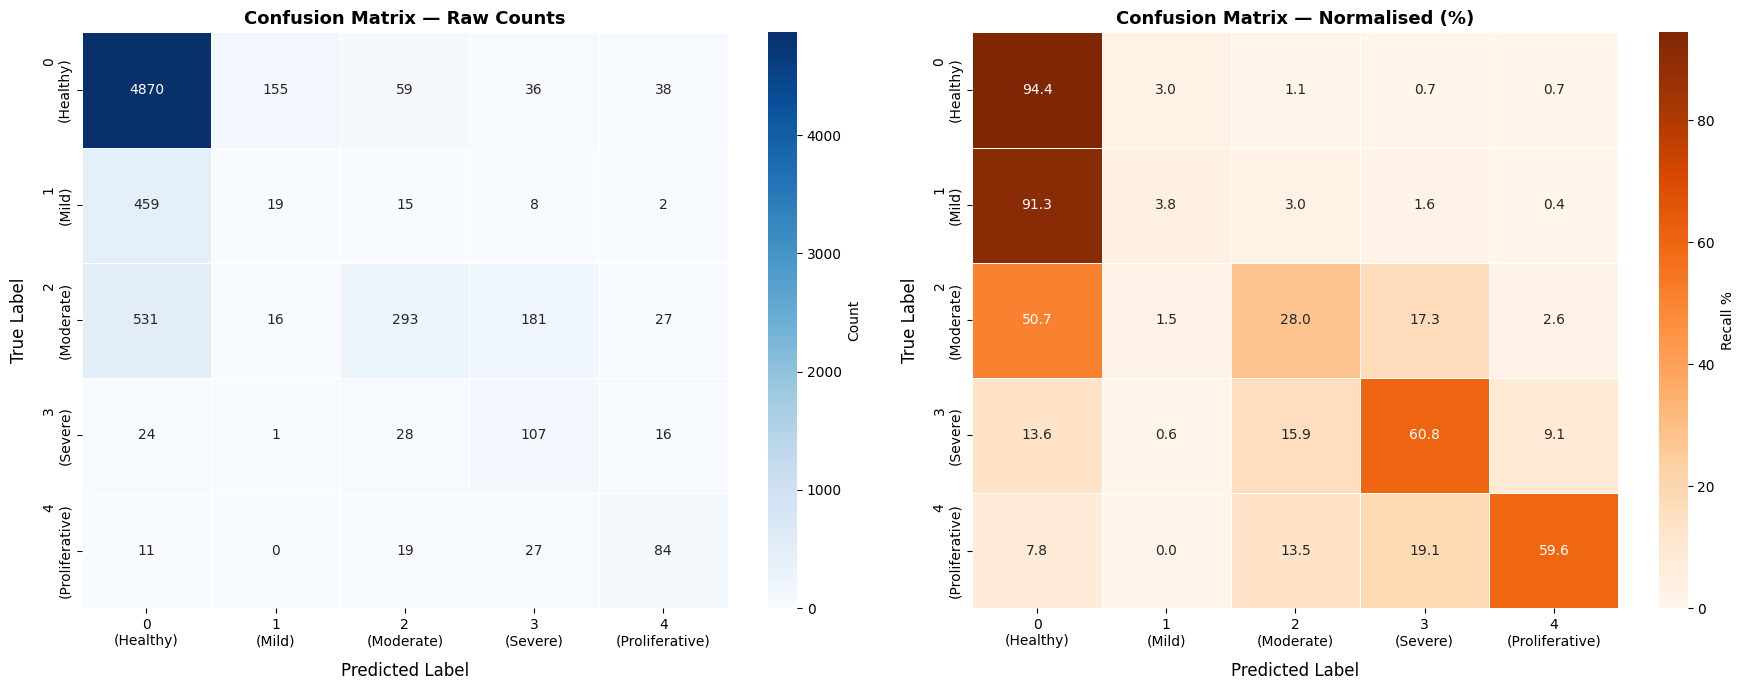

In [7]:
def plot_confusion_matrices(all_labels_eval, all_preds_eval):

    class_names = ['0\n(Healthy)','1\n(Mild)','2\n(Moderate)','3\n(Severe)','4\n(Proliferative)']

    # Compute confusion matrix (raw counts)
    cm      = confusion_matrix(all_labels_eval, all_preds_eval)
    # Normalize by row to get percentage (recall per class)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # row %

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Raw Counts Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Count'}, ax=axes[0])
    
    axes[0].set_xlabel('Predicted Label', fontsize=12, labelpad=10)
    axes[0].set_ylabel('True Label',      fontsize=12, labelpad=10)
    axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13, fontweight='bold')

    #  Normalised % Matrix
    sns.heatmap( cm_norm, annot=True, fmt='.1f', cmap='Oranges', xticklabels=class_names, yticklabels=class_names, linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Recall %'}, ax=axes[1])
    
    axes[1].set_xlabel('Predicted Label', fontsize=12, labelpad=10)
    axes[1].set_ylabel('True Label',      fontsize=12, labelpad=10)
    axes[1].set_title('Confusion Matrix — Normalised (%)', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_confusion_matrices(all_labels_eval, all_preds_eval);

> Interpretation:
>
> **Class by Class Analysis:**
>
> - **Class 0 – Healthy:** Demonstrates excellent performance for healthy cases, achieving near-perfect recall. However, this strong performance also reflects a majority class bias, where the model tends to favour predicting the dominant class, contributing to inflated overall accuracy.
>   
> - **Class 1 – Mild:** Represents the most critical failure point of the model. Only a very small proportion of mild cases are correctly classified, while the vast majority are misclassified as healthy. As a result, early detection capability is severely limited.
>   
> - **Class 2 – Moderate:** Shows high precision but very low recall for moderate DR. This means that predictions labeled as Grade 2 are generally correct, but the model fails to identify most actual moderate cases. A large portion of these cases are incorrectly classified as Grade 0.
>   
> - **Class 3 – Severe:** Performance improves significantly for severe DR. The model achieves moderate-to-high recall, indicating a stronger ability to detect more advanced disease stages. However, precision remains relatively low, suggesting the presence of false positives. Despite this, the model demonstrates a clear improvement compared to earlier grades.
> 
> - **Class 4 – Proliferative:** Achieves a balanced performance, with moderate precision and recall. This indicates that the model is reasonably effective in identifying sight-threatening conditions, which is crucial for clinical prioritization.
--- 

####  <font color = blue> **III. ROC and Precision-Recall Curve Analysis** </font>

ROC and Precision–Recall (PR) curves were generated using the predicted probabilities and true labels to evaluate the model beyond accuracy-based metrics. This helps assess how well the model separates classes and handles imbalanced data. While ROC-AUC measures overall separability between healthy and diseased cases, the Precision–Recall curves give deeper insight into how well each severity class is handled, particularly in the presence of class imbalance.

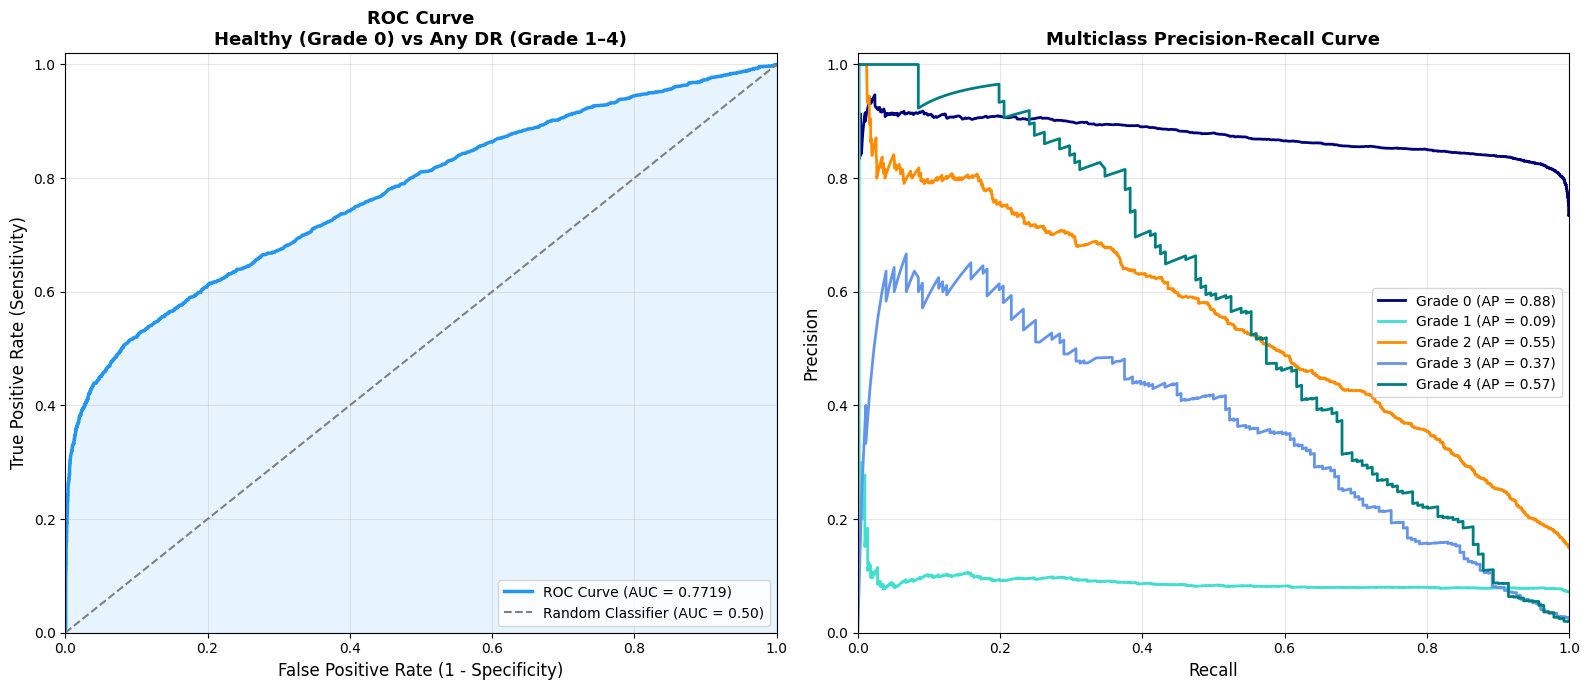

ROC-AUC (Healthy vs Any DR): 0.7719
Average Precision — Grade 0: 0.8758
Average Precision — Grade 1: 0.0900
Average Precision — Grade 2: 0.5502
Average Precision — Grade 3: 0.3689
Average Precision — Grade 4: 0.5715


In [8]:
def plot_roc_and_pr_curves(all_labels_eval, all_probs):

    all_probs = np.array(all_probs)

    # Binary classification setup (Healthy vs Any DR)
    # Convert labels: 0 = Healthy, 1–4 = Diseased
    binary_true  = (np.array(all_labels_eval) > 0).astype(int)

    # Sum probabilities of all disease classes to get "Disease score"
    binary_score = all_probs[:, 1:].sum(axis=1)

    # ROC Curve computation
    # FPR = false positive rate, TPR = true positive rat
    fpr, tpr, _ = roc_curve(binary_true, binary_score)
    # Area under ROC curve
    roc_auc     = auc(fpr, tpr)

    # Multi-class one-vs-rest setup for PR curves
    # Convert labels into one-hot encoded format
    Y         = label_binarize(all_labels_eval, classes=[0, 1, 2, 3, 4])
    n_classes = Y.shape[1]
    colors    = ['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal']

    pr_data = []

    # Compute Precision-Recall curve for each class
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(Y[:, i], all_probs[:, i])
        ap = average_precision_score(Y[:, i], all_probs[:, i])
        pr_data.append((precision, recall, ap))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # ROC Curve Plot (Binary)
    ax1.plot(fpr, tpr, color='#2196F3', linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    ax1.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
    ax1.plot([0, 1], [0, 1],  color='gray', linestyle='--', linewidth=1.5,  label='Random Classifier (AUC = 0.50)')
    ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    ax1.set_ylabel('True Positive Rate (Sensitivity)',      fontsize=12)
    ax1.set_title('ROC Curve\nHealthy (Grade 0) vs Any DR (Grade 1–4)', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10, loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1.02])

    # Multiclass PR Curve
    for i, (precision, recall, ap) in enumerate(pr_data):
        ax2.plot(recall, precision, color=colors[i], linewidth=2, label=f'Grade {i} (AP = {ap:.2f})')
        
    ax2.set_xlabel('Recall',    fontsize=12)
    ax2.set_ylabel('Precision', fontsize=12)
    ax2.set_title('Multiclass Precision-Recall Curve', fontsize=13, fontweight='bold')
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([0, 1])
    ax2.set_ylim([0, 1.02])

    plt.tight_layout()
    plt.show()

    # Print evaluation summary
    print(f"ROC-AUC (Healthy vs Any DR): {roc_auc:.4f}")
    # Print Average Precision for each class
    for i, (_, _, ap) in enumerate(pr_data):
        print(f"Average Precision — Grade {i}: {ap:.4f}")

plot_roc_and_pr_curves(all_labels_eval, all_probs);

> Interpretation:
> 
> **ROC Curve Analysis**
>
> - The model achieves an Area Under the Curve (AUC) of 0.7719, indicating a moderate discriminative ability.
>
> - The initial steep rise indicates that the model can achieve high specificity while still detecting a reasonable proportion of diseased cases, making it effective at minimizing false positives in early operating regions. However, as sensitivity increases, the curve flattens, suggesting that achieving near-perfect detection of all diseased cases would require accepting a substantial increase in false positives.
>
> **Precision–Recall Analysis**
>
> - **Grade 0 (Healthy):** AP = 0.88
>
> The model demonstrates strong and consistent performance for healthy cases. The PR curve remains high across recall levels, indicating that most healthy images are correctly identified with minimal false positives.
>
> - **Grade 1 (Mild):** AP = 0.09
> 
> This is the weakest performing class. The PR curve remains near the baseline, indicating that the model is unable to reliably distinguish mild DR from healthy cases.
>
> - **Grade 2 (Moderate):** AP ≈ 0.55
>
> This represents a notable strength of the model. It maintains relatively good precision for moderate DR, which is clinically significant as this stage often marks the transition to referable disease requiring closer monitoring or treatment.
>
> - **Grade 3 (Severe):** AP ≈ 0.37
> 
> Performance is more limited, likely due to feature overlap with adjacent classes. Severe DR shares characteristics with both moderate and proliferative stages, making it difficult for the model to establish clear decision boundaries.
>
> - **Grade 4 (Proliferative):** AP = 0.57
> 
> The model performs relatively well on severe disease cases. This can be attributed to the presence of distinct visual features (e.g., abnormal blood vessel growth and hemorrhages), which are easier for the model to learn and identify.
>
> **Overall, the model demonstrates practical utility for screening and detection of advanced diabetic retinopathy, but its limited sensitivity to early-stage disease restricts its effectiveness in comprehensive clinical diagnosis.**
--- 

####  <font color = blue> **IV. Loss and QWK Curve Analysis** </font>

This analysis provides a clear view of model learning behaviour over time. Loss curves show optimization progress, while QWK curves reflect true predictive quality. Together, they help identify the most effective training stage and ensure the final model is selected based on validation performance rather than the last epoch.

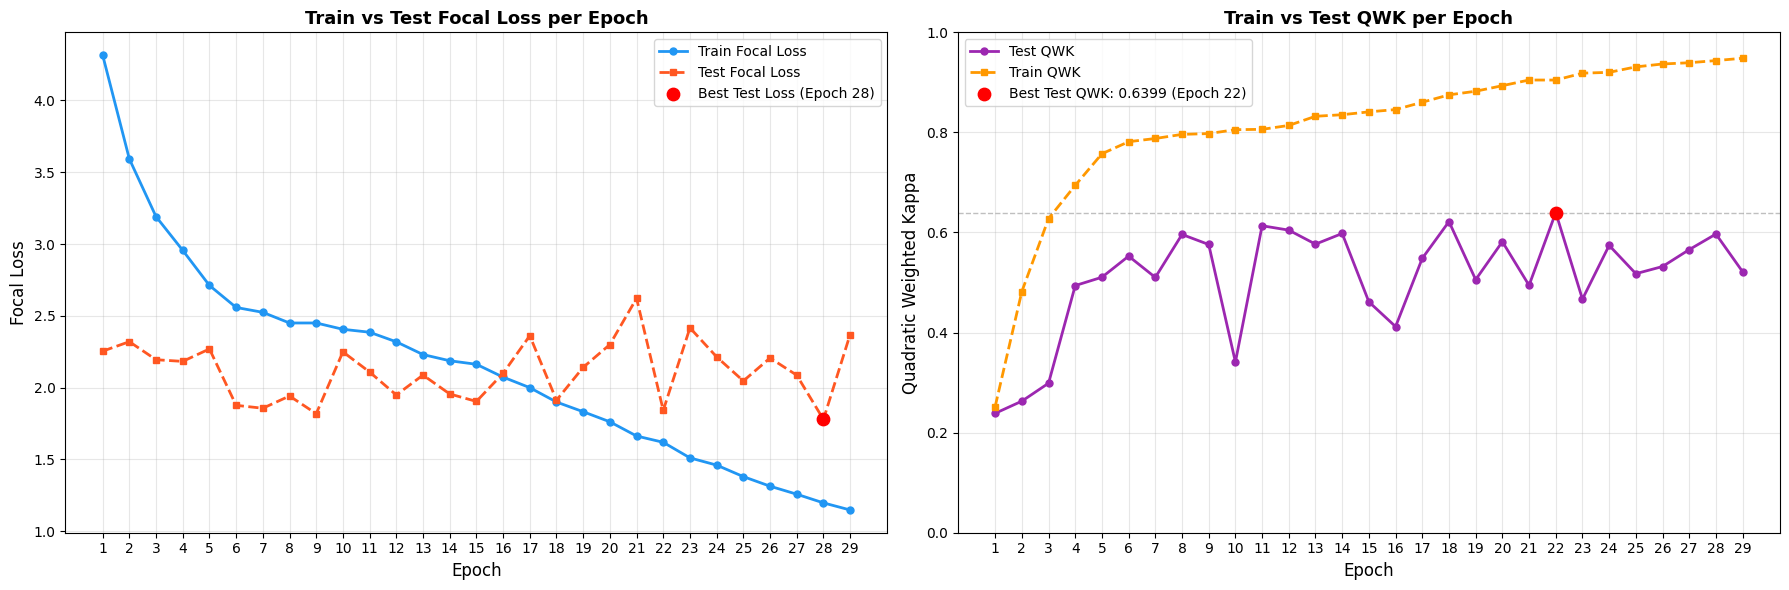

In [9]:
def plot_training_curves(train_losses, test_losses, train_kappa_scores, test_kappa_scores, unfreeze_epoch=999):

    epochs_ran = list(range(1, len(train_losses) + 1))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot Loss Curves
    # Plot training focal loss─
    ax1.plot(epochs_ran, train_losses, marker='o', linewidth=2, markersize=5, color='#2196F3', label='Train Focal Loss')
    # Plot test/validation focal loss
    ax1.plot(epochs_ran, test_losses, marker='s', linewidth=2, markersize=5, color='#FF5722', linestyle='--', label='Test Focal Loss')

    # Identify best test loss epoch (minimum loss)
    best_loss_ep = int(np.argmin(test_losses)) + 1
    # Highlight best test loss point
    ax1.scatter(best_loss_ep, min(test_losses), color='red', zorder=5, s=80, label=f'Best Test Loss (Epoch {best_loss_ep})')

    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Focal Loss', fontsize=12)
    ax1.set_title('Train vs Test Focal Loss per Epoch', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(epochs_ran)

    # Plot QWK Curves
    # Plot test QWK scores
    ax2.plot(epochs_ran, test_kappa_scores, marker='o', linewidth=2, markersize=5, color='#9C27B0', label='Test QWK')
    # Plot training QWK scores
    ax2.plot(epochs_ran, train_kappa_scores, marker='s', linewidth=2, markersize=5, color='#FF9800', linestyle='--', label='Train QWK')

    # Identify best test QWK epoch (maximum QWK)
    best_kappa_ep = int(np.argmax(test_kappa_scores)) + 1
    best_kappa_test = max(test_kappa_scores)

    # Highlight best QWK point
    ax2.scatter(best_kappa_ep, best_kappa_test,  color='red', zorder=5, s=80, label=f'Best Test QWK: {best_kappa_test:.4f} (Epoch {best_kappa_ep})')

    ax2.axhline(best_kappa_test, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Quadratic Weighted Kappa', fontsize=12)
    ax2.set_title('Train vs Test QWK per Epoch', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)
    ax2.set_xticks(epochs_ran)

    plt.tight_layout()
    plt.show()

plot_training_curves(train_losses, test_losses, train_kappa_scores, test_kappa_scores);

> Interpretation:
>
> **Loss Curve Analysis:**
>
> - Starts with a much higher training loss (around 4.3), which is expected since it is trained from scratch. However, the loss decreases in a smooth and consistent manner across epochs. This type of curve is typical for a well-designed custom model and suggests stable learning throughout training.
> 
> **QWK Curve Analysis:**
>
> - The model achieves a higher peak QWK of 0.6399. Although a gap between training and testing still exists, the test curve is more dynamic, with occasional drops followed by recovery. These fluctuations suggest that the model encounters challenging batches but is able to recover, indicating a stable optimization process.
>
> - RetinalNet’s smooth training loss curve indicates that the architecture, along with techniques such as Kaiming initialization and the warmup learning rate schedule, provides stable and effective learning from scratch.
>
> - RetinalNet reaches its best performance later (around Epoch 22), compared to EfficientNet. This reflects the nature of training from scratch, which requires more time but can eventually achieve better results.
---

####  <font color = blue> **V. Grad-CAM Analysis** </font>

Grad-CAM visualizations represent where the model focuses when making correct and incorrect predictions across all diabetic retinopathy grades. Areas shown in red and yellow indicate high importance, while blue regions have little influence on the prediction.

Running inference on test set for error analysis...


Scanning test set:  21%|██▏       | 1510/7026 [00:02<00:08, 620.79it/s] 


  Early exit at image 1510 — all grades have 5 correct + 5 incorrect candidates.
  Scanned 232 images total.
  Correct   candidates per grade: {0: 72, 1: 5, 2: 5, 3: 12, 4: 15}
  Incorrect candidates per grade: {0: 5, 1: 95, 2: 13, 3: 5, 4: 5}


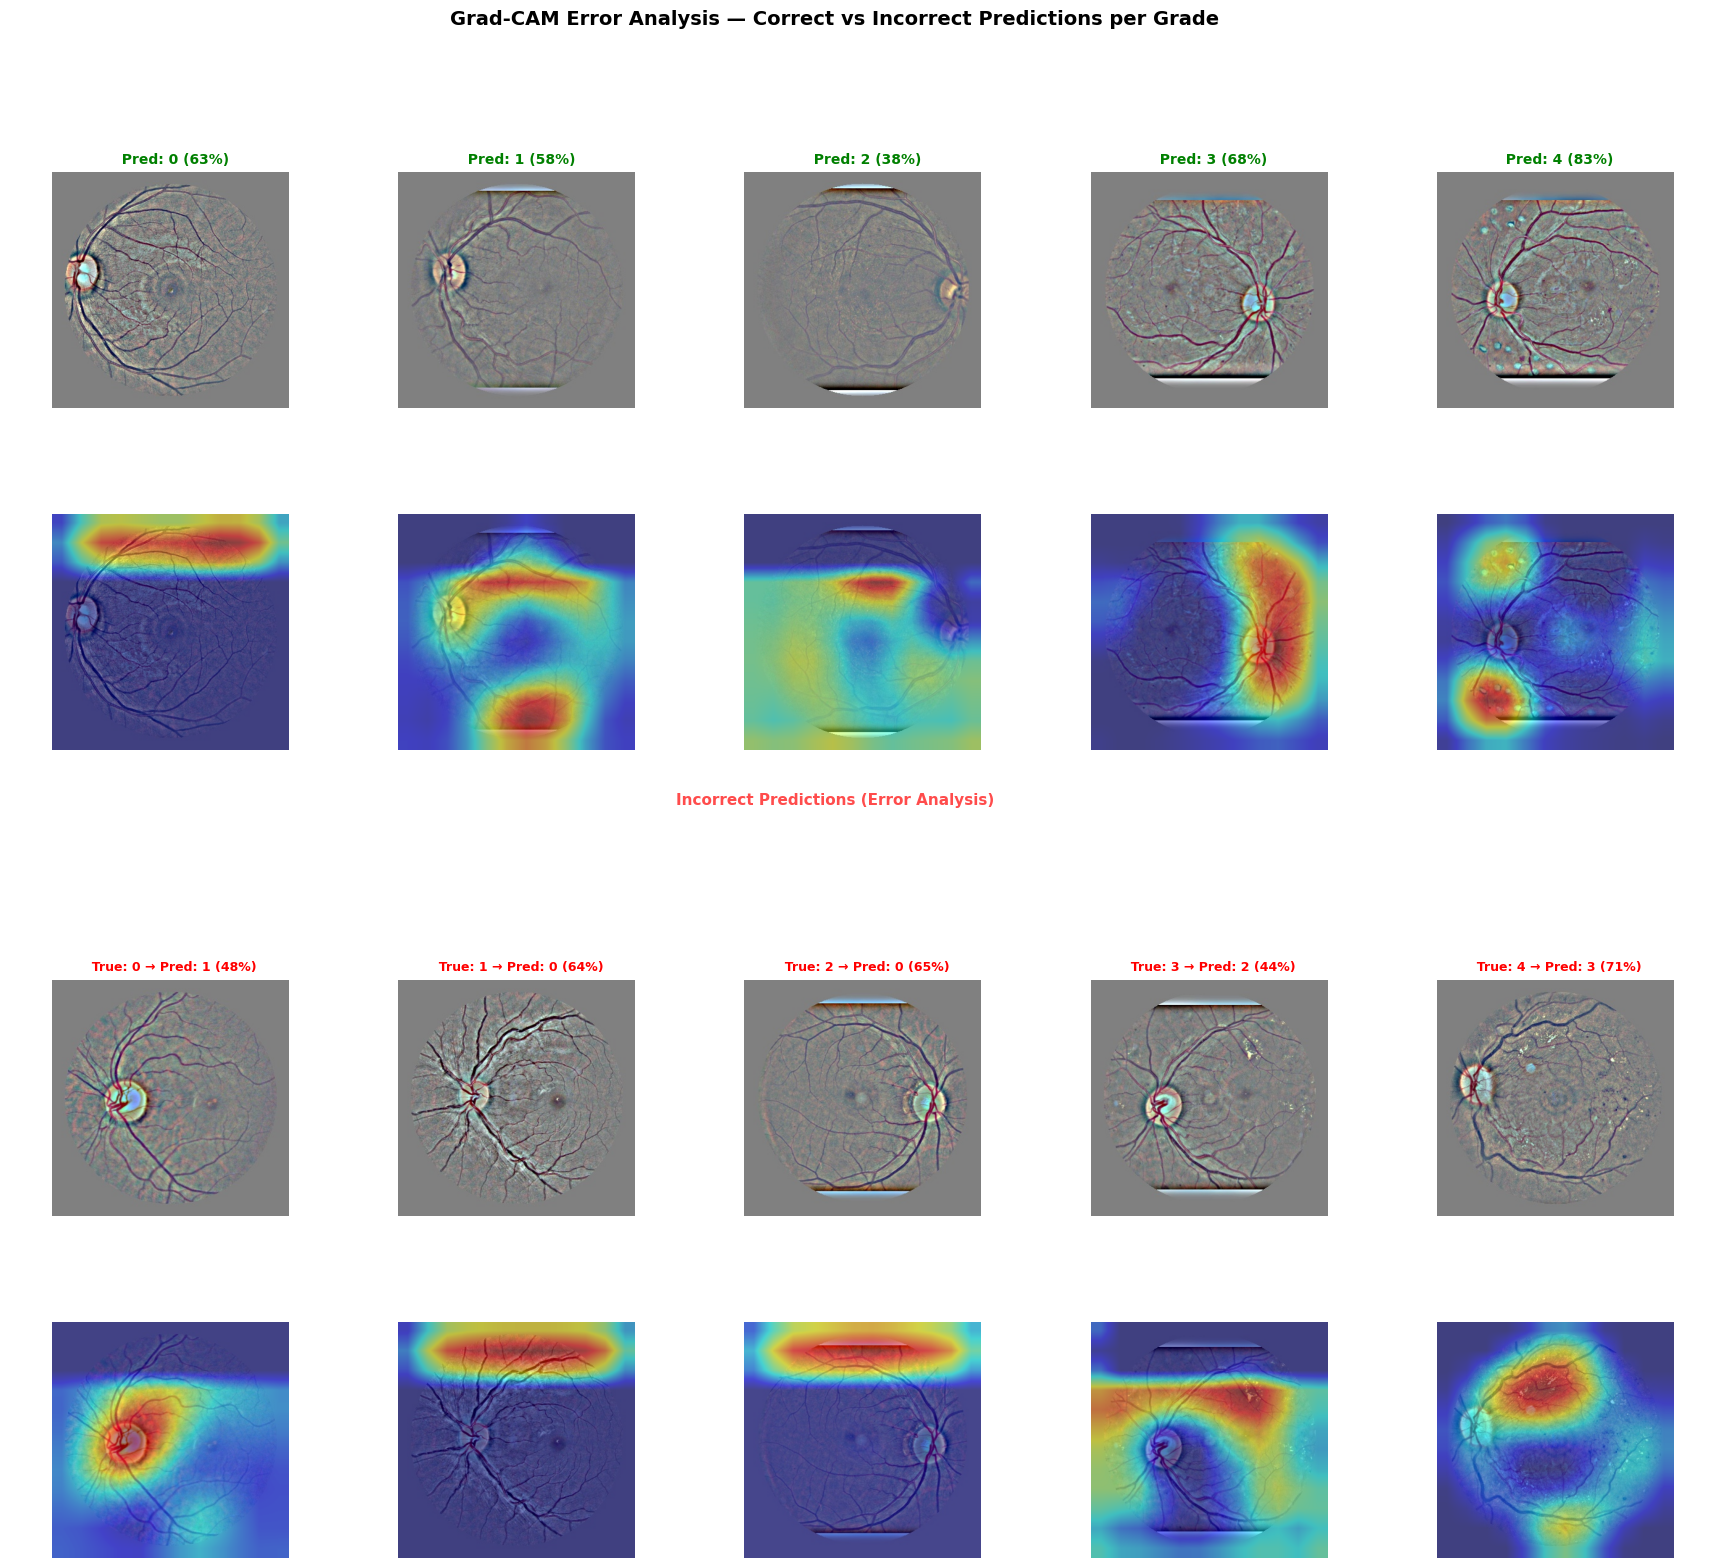

In [10]:
# Select last convolutional layer for Grad-CAM
target_layers = [model.stage4[-1].bn2]

print("Running inference on test set for error analysis...")

model.eval()
sample_records = []  
# Limit number of samples per class for balance
MAX_PER_GRADE    = 5  
# Track correct and incorrect counts per grade
correct_counts   = {g: 0 for g in range(5)}
incorrect_counts = {g: 0 for g in range(5)}

# Scan test set and collect predictions
for idx in tqdm(range(len(test_df)), desc="Scanning test set"):
    true_label = int(test_df.iloc[idx]['level'])

    if (correct_counts[true_label]   >= MAX_PER_GRADE and
            incorrect_counts[true_label] >= MAX_PER_GRADE):
       
        if all(correct_counts[g]   >= MAX_PER_GRADE and
               incorrect_counts[g] >= MAX_PER_GRADE for g in range(5)):
            print(f"  Early exit at image {idx} — all grades have "
                  f"{MAX_PER_GRADE} correct + {MAX_PER_GRADE} incorrect candidates.")
            break
        continue  
    
    # Load image path
    img_name = str(test_df.iloc[idx]['image']).strip() + ".jpeg"
    img_path = os.path.join(TRAIN_IMG_DIR, img_name)

    # Load and resize image
    orig_img = Image.open(img_path).convert("RGB")
    orig_img = orig_img.resize((384, 384))

    # Normalize using ImageNet statistics
    tensor       = F.to_tensor(orig_img)
    tensor       = F.normalize(tensor,
                               mean=[0.485, 0.456, 0.406],
                               std =[0.229, 0.224, 0.225])
    input_tensor = tensor.unsqueeze(0).to(device)

    # Run inference without gradients
    with torch.no_grad():
        outputs    = model(input_tensor)
        pred_label = int(torch.argmax(outputs, dim=1).item())
        confidence = torch.softmax(outputs, dim=1)[0, pred_label].item()

    sample_records.append((idx, true_label, pred_label, confidence))

    if true_label == pred_label:
        correct_counts[true_label] += 1
    else:
        incorrect_counts[true_label] += 1

# Print summary of scanned samples
print(f"  Scanned {len(sample_records)} images total.")
print(f"  Correct   candidates per grade: {correct_counts}")
print(f"  Incorrect candidates per grade: {incorrect_counts}")

# Select one correct + one incorrect per clas
correct   = {}   
incorrect = {}  

for record in sample_records:
    idx, true_label, pred_label, confidence = record
    # First correct prediction per class
    if true_label not in correct and true_label == pred_label:
        correct[true_label] = record
    # First incorrect prediction per class
    if true_label not in incorrect and true_label != pred_label:
        incorrect[true_label] = record
    if len(correct) == 5 and len(incorrect) == 5:
        break

# Check missing cases
for g in range(5):
    if g not in correct:
        print(f"  Warning: No correct prediction found for Grade {g}")
    if g not in incorrect:
        print(f"  Warning: No incorrect prediction found for Grade {g}")

# Function: Generate Grad-Cam Images
def render_gradcam_row(cam, records_dict, axes_row, row_label):

    for grade in range(5):
        ax = axes_row[grade]

        if grade not in records_dict:
            ax.text(0.5, 0.5, 'No sample\nfound', ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray')
            ax.axis('off')
            continue

        idx, true_label, pred_label, confidence = records_dict[grade]

        # Load image
        img_name = str(test_df.iloc[idx]['image']).strip() + ".jpeg"
        img_path = os.path.join(TRAIN_IMG_DIR, img_name)
        orig_img = Image.open(img_path).convert("RGB")
        orig_img = orig_img.resize((384, 384))
        orig_np  = np.array(orig_img).astype(np.float32) / 255.0

        # Prepare tensor
        tensor       = F.to_tensor(orig_img)
        tensor       = F.normalize(tensor,
                                   mean=[0.485, 0.456, 0.406],
                                   std =[0.229, 0.224, 0.225])
        input_tensor = tensor.unsqueeze(0).to(device)

        # Generate Grad-CAM heatmap
        targets   = [ClassifierOutputTarget(pred_label)]
        grayscale = cam(input_tensor=input_tensor, targets=targets)
        heatmap   = show_cam_on_image(orig_np, grayscale[0], use_rgb=True)
        ax.imshow(heatmap)

        title_color = 'green' if true_label == pred_label else 'red'
        outcome     = 'Correct' if true_label == pred_label else 'Wrong'
        ax.set_title(f'{outcome}\nTrue: {true_label}  Pred: {pred_label} ({confidence:.0%})', fontsize=9, fontweight='bold', color=title_color)
        ax.axis('off')

    # Row label on the first axis
    axes_row[0].set_ylabel(row_label, fontsize=11, fontweight='bold')

fig = plt.figure(figsize=(22, 18))

gs = gridspec.GridSpec( 5, 5, figure=fig, height_ratios=[4, 4, 0.3, 4, 4], hspace=0.55, wspace=0.08)
# Axes for correct predictions
axes_correct_orig  = [fig.add_subplot(gs[0, c]) for c in range(5)]
axes_correct_cam   = [fig.add_subplot(gs[1, c]) for c in range(5)]
# Axes for incorrect predictions
axes_incorrect_orig = [fig.add_subplot(gs[3, c]) for c in range(5)]
axes_incorrect_cam  = [fig.add_subplot(gs[4, c]) for c in range(5)]

for c in range(5):
    ax_div = fig.add_subplot(gs[2, c])
    ax_div.set_facecolor('#CCCCCC')
    ax_div.axis('off')

# Class labels
grade_labels = ['Grade 0\n(Healthy)', 'Grade 1\n(Mild)','Grade 2\n(Moderate)', 'Grade 3\n(Severe)','Grade 4\n(Proliferative)']

for c, lbl in enumerate(grade_labels):
    axes_correct_orig[c].set_title(lbl, fontsize=10, fontweight='bold', color='#333333', pad=6)

# Section labels
axes_correct_orig[0].set_ylabel('Original\n(Correct)', fontsize=10,  fontweight='bold', color='green')
axes_correct_cam[0].set_ylabel('Grad-CAM\n(Correct)', fontsize=10,  fontweight='bold', color='green')
axes_incorrect_orig[0].set_ylabel('Original\n(Incorrect)', fontsize=10,  fontweight='bold', color='red')
axes_incorrect_cam[0].set_ylabel('Grad-CAM\n(Incorrect)', fontsize=10, fontweight='bold', color='red')

# Generate Grad-CAM visualizations
with GradCAM(model=model, target_layers=target_layers) as cam:

    # Correct predictions
    for grade in range(5):
        ax_orig = axes_correct_orig[grade]
        ax_cam  = axes_correct_cam[grade]

        if grade not in correct:
            for ax in [ax_orig, ax_cam]:
                ax.text(0.5, 0.5, 'No sample\nfound',  ha='center', va='center',  transform=ax.transAxes, fontsize=9, color='gray')
                ax.axis('off')
            continue

        idx, true_label, pred_label, confidence = correct[grade]

        # Load image
        img_name = str(test_df.iloc[idx]['image']).strip() + ".jpeg"
        img_path = os.path.join(TRAIN_IMG_DIR, img_name)
        orig_img = Image.open(img_path).convert("RGB").resize((384, 384))
        orig_np  = np.array(orig_img).astype(np.float32) / 255.0

        # Preprocess
        tensor       = F.to_tensor(orig_img)
        tensor       = F.normalize(tensor, mean=[0.485, 0.456, 0.406],
                                           std =[0.229, 0.224, 0.225])
        input_tensor = tensor.unsqueeze(0).to(device)

        # Grad-CAM
        targets   = [ClassifierOutputTarget(pred_label)]
        grayscale = cam(input_tensor=input_tensor, targets=targets)
        heatmap   = show_cam_on_image(orig_np, grayscale[0], use_rgb=True)

        ax_orig.imshow(orig_np)
        ax_orig.set_title(f'  Pred: {pred_label} ({confidence:.0%})', fontsize=10, fontweight='bold', color='green')
        ax_orig.axis('off')
        ax_cam.imshow(heatmap)
        ax_cam.axis('off')

    # Incorrect predictions
    for grade in range(5):
        ax_orig = axes_incorrect_orig[grade]
        ax_cam  = axes_incorrect_cam[grade]

        if grade not in incorrect:
            for ax in [ax_orig, ax_cam]:
                ax.text(0.5, 0.5, 'No sample\nfound',  ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray')
                ax.axis('off')
            continue

        idx, true_label, pred_label, confidence = incorrect[grade]

        # Load image
        img_name = str(test_df.iloc[idx]['image']).strip() + ".jpeg"
        img_path = os.path.join(TRAIN_IMG_DIR, img_name)
        orig_img = Image.open(img_path).convert("RGB").resize((384, 384))
        orig_np  = np.array(orig_img).astype(np.float32) / 255.0

        # Preprocess
        tensor       = F.to_tensor(orig_img)
        tensor       = F.normalize(tensor, mean=[0.485, 0.456, 0.406],
                                           std =[0.229, 0.224, 0.225])
        input_tensor = tensor.unsqueeze(0).to(device)

        # Grad-CAM
        targets   = [ClassifierOutputTarget(pred_label)]
        grayscale = cam(input_tensor=input_tensor, targets=targets)
        heatmap   = show_cam_on_image(orig_np, grayscale[0], use_rgb=True)

        ax_orig.imshow(orig_np)
        ax_orig.set_title(f'  True: {true_label} → Pred: {pred_label} ({confidence:.0%})',  fontsize=9, fontweight='bold', color='red')
        ax_orig.axis('off')
        ax_cam.imshow(heatmap)
        ax_cam.axis('off')

# Overall titles
fig.text(0.5, 0.97, 'Grad-CAM Error Analysis — Correct vs Incorrect Predictions per Grade', ha='center', va='top', fontsize=14, fontweight='bold')
fig.text(0.5, 0.535, 'Incorrect Predictions (Error Analysis)', ha='center', va='top', fontsize=11, fontweight='bold', color='red', alpha=0.7)
plt.tight_layout()
plt.show()

> Interpretation:
>
> - RetinalNet shows a clear and structured attention pattern that helps explain its strong overall performance.
> 
> - In correctly classified examples, especially for Grades 3 and 4, the model tends to focus on central regions of the retina, often forming a circular or halo-like pattern. This indicates that the model is paying attention to clinically relevant areas and major blood vessels, where features like haemorrhages are typically found.
>
> - However, some limitations can also be observed. In certain incorrect predictions, the heatmaps display horizontal striping patterns. This suggests the presence of a spatial bias, likely introduced during preprocessing steps such as cropping or padding. A clear example of this can be seen in cases where a Grade 2 image is misclassified as Grade 0. In such cases, the model’s attention shifts towards the edges of the image instead of the central retinal region, causing it to miss important pathological features.

>
> **RetinalNet captures broader patterns across the retina, allowing it to better understand overall structure and context.**
>
> **In terms of failure modes, RetinalNet can be influenced by spatial biases introduced during preprocessing. This suggests that improvements such as tighter cropping around the retina could enhance performance.**
---

####  <font color = blue> **VI. Reliability Diagram Analysis** </font>

Reliability diagrams are used to evaluate model calibration, which measures how well predicted probabilities reflect actual outcomes. In a well-calibrated model, predictions should closely match real-world frequencies. This is represented by the diagonal line in the diagram, where perfect calibration lies. The closer the model’s curve is to this line, the more reliable its probability.

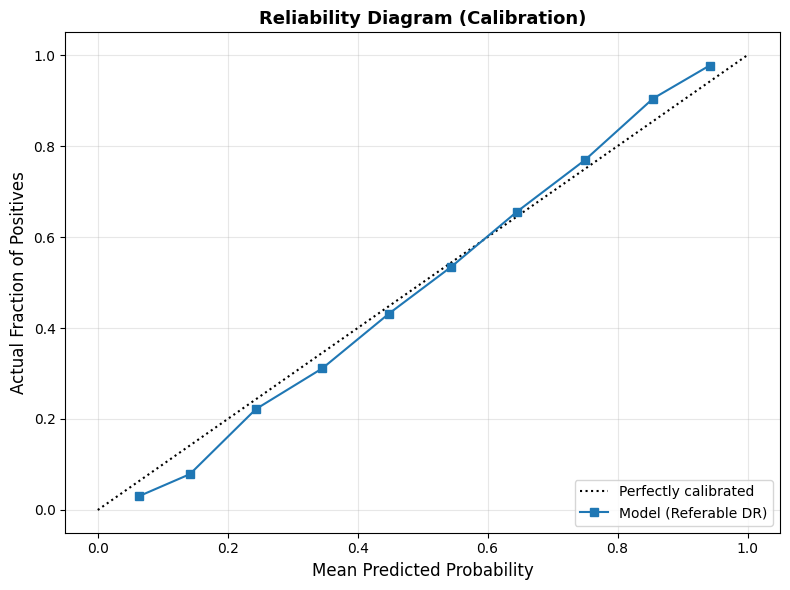

In [11]:
def plot_calibration_curve(all_labels_eval, all_probs):

    # Convert inputs to NumPy arrays for easier processing
    all_probs = np.array(all_probs)
    all_labels_eval = np.array(all_labels_eval)

    # Check that predictions and labels have the same length
    assert len(all_labels_eval) == len(all_probs), (
        f"Length mismatch: all_labels_eval has {len(all_labels_eval)} samples "
        f"but all_probs has {len(all_probs)} samples. "
        f"Make sure both come from the same evaluation loop."
    )

    plt.figure(figsize=(8, 6))
    # Plot perfectly calibrated reference line (ideal model)
    plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

    # Convert multi-class problem into binary classification:
    # Class 0–1 = non-referable, Class 2–4 = referable 
    bin_labels      = (all_labels_eval >= 2).astype(int)
    referable_probs = all_probs[:, 2:].sum(axis=1)

    # Compute calibration curve (reliability diagram data)
    prob_true, prob_pred = calibration_curve(bin_labels, referable_probs, n_bins=10)

    # Plot model calibration curve
    plt.plot(prob_pred, prob_true, "s-", label="Model (Referable DR)")

    plt.ylabel("Actual Fraction of Positives", fontsize=12)
    plt.xlabel("Mean Predicted Probability", fontsize=12)
    plt.title('Reliability Diagram (Calibration)', fontsize=13, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_calibration_curve(all_labels_eval, all_probs);

> Intepretation:
>
> - RetinalNet shows a curve that closely follows the diagonal line across most probability ranges.
> 
> - This indicates strong calibration, where predicted probabilities align well with actual outcomes. In other words, when the model predicts a certain risk level, it is generally accurate in reflecting the true likelihood of disease.
>
> - This is highly desirable in medical applications, as clinicians can rely on the model’s confidence scores when making decisions.
>
---

### </font> <font color = #41EA46> **5: Prevalence Alignment Analysis**</font>

A prevalence alignment analysis was conducted to evaluate the models’ suitability for clinical deployment. This approach goes beyond standard validation metrics by examining how the models behave when applied to a large, real-world dataset. In this case, EfficientNet-B4 model was used to generate predictions for an unlabeled dataset containing approximately 53,000 retinal images (around 53GB in total). The predicted class distributions from this dataset were then compared against the known distribution of the training data. This comparison helps identify systemic bias in the models.

**External Inference Pipeline:** This section describes the final inference pipeline used to generate predictions on unseen test images and store results for downstream analysis.

In [12]:
# Set device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Inference preprocessing function
# Ensures test images are processed exactly like training images
def preprocess_for_inference(image):
    # Resize image to match model input size
    image = F.resize(image, [384, 384])
    image = F.to_tensor(image)
    # Normalize using ImageNet mean and std (must match training pipeline)
    image = F.normalize(image,
                        mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225])
    return image

# Load trained model for inference
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

model.eval()
results = []

# Get all JPEG images from holdout test directory
image_files = [f for f in os.listdir(UNLABELED_TEST_DIR) if f.lower().endswith('.jpeg')]

# Run inference on unseen test images
with torch.no_grad():
    for img_name in tqdm(image_files, desc="Generate Predictions for Unlabeled Images:"):
        img_path = os.path.join(UNLABELED_TEST_DIR, img_name)
        image = Image.open(img_path).convert("RGB")
        # Preprocess image and add batch dimension
        img_tensor = preprocess_for_inference(image).unsqueeze(0).to(device)
        outputs = model(img_tensor)
        # Get predicted class (highest probability)
        predicted_grade = int(torch.argmax(outputs, dim=1).item())
        confidence      = torch.softmax(outputs, dim=1)[0, predicted_grade].item() 

        # Store prediction result
        results.append({'image': img_name, 'confidence': round(confidence, 4), 'predicted_level': predicted_grade})

# Save predictions to CSV file
df_preds = pd.DataFrame(results)
df_preds.to_csv(SAVE_PREDICTIONS_PATH, index=False)

Generate Predictions for Unlabeled Images: 100%|██████████| 53576/53576 [15:31<00:00, 57.54it/s]


**Training vs. Model Prediction Distribution Analysis:** This section compares the true class distribution in the training dataset with the distribution of model predictions on the unseen holdout set. The below charts present a side-by-side comparison of two distributions: the actual class distribution in the training dataset (left panel) and the distribution of predictions generated by each model on the unlabelled test set (right panel). This type of visualization is a well-established diagnostic tool in medical AI research for identifying majority class bias. Ideally, a well-calibrated model should produce a prediction distribution that closely reflects the true underlying class distribution.

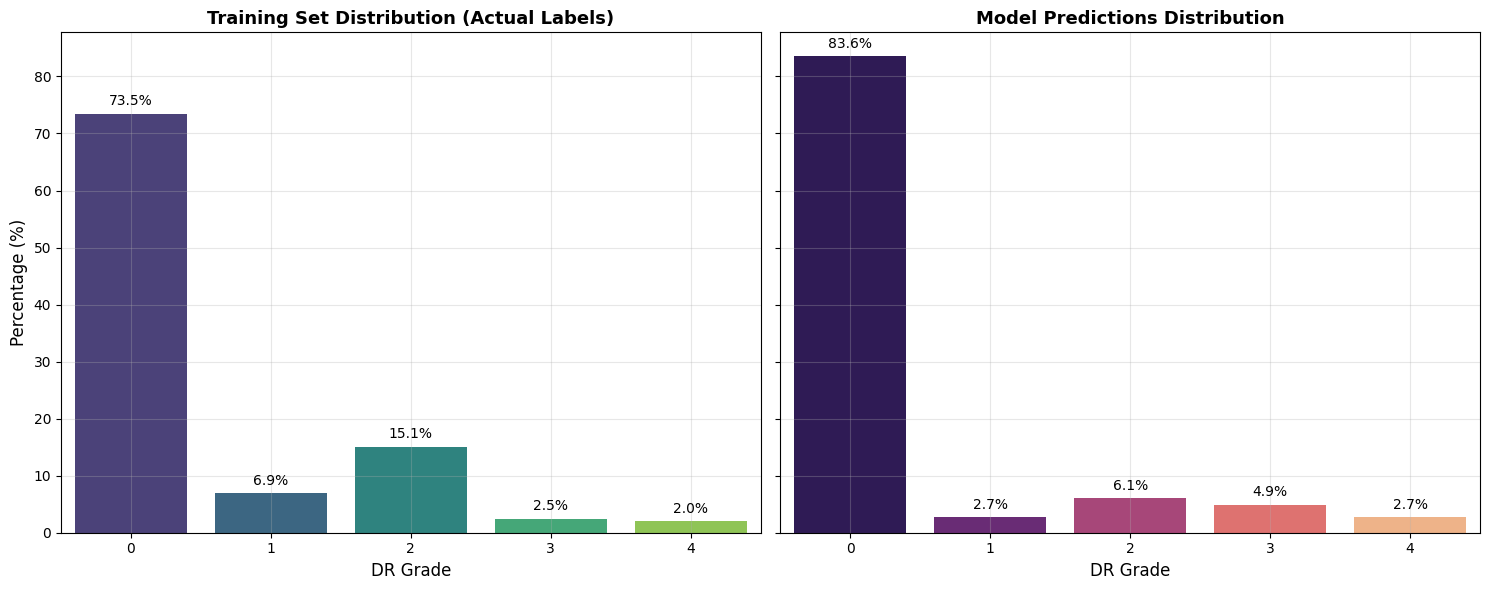

In [15]:
# Load saved model predictions from CSV file
predictions_df = pd.read_csv(SAVE_PREDICTIONS_PATH)

def plot_distribution_comparison(train_df, predictions_df):
    
    # Calculate training set class distribution (percentage)
    train_dist = train_df['level'].value_counts(normalize=True).sort_index() * 100
    # Calculate prediction distribution (percentage) 
    predictions_dist = predictions_df['predicted_level'].value_counts(normalize=True).sort_index() * 100

    # Ensure all classes (0–4) exist in both distributions
    grades = [0, 1, 2, 3, 4]
    train_dist = train_dist.reindex(grades, fill_value=0)
    predictions_dist = predictions_dist.reindex(grades, fill_value=0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    # Training set distribution
    sns.barplot(x=train_dist.index, y=train_dist.values, ax=ax1, palette="viridis")
    ax1.set_title('Training Set Distribution (Actual Labels)', fontsize=13, fontweight='bold')
    ax1.set_xlabel('DR Grade', fontsize=12)
    ax1.set_ylabel('Percentage (%)', fontsize=12)
    ax1.grid(True, alpha=0.3)

    # Prediction distribution
    sns.barplot(x=predictions_dist.index, y=predictions_dist.values, ax=ax2, palette="magma")
    ax2.set_title('Model Predictions Distribution', fontsize=13, fontweight='bold')
    ax2.set_xlabel('DR Grade', fontsize=12)
    ax2.set_ylabel('Percentage (%)', fontsize=12)
    ax2.grid(True, alpha=0.3)

    # Add percentage labels on bars
    for ax in [ax1, ax2]:
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)

    plt.tight_layout()
    plt.show()

plot_distribution_comparison(train_df, predictions_df);

> Interpretation:
>
> - RetinalNet also over-predicts Grade 0, assigning it to 83.6% of test images. However, this is 5.2 percentage points lower than EfficientNet, indicating a reduced level of bias.
>
> - More importantly, RetinalNet distributes predictions more evenly across diseased classes. Grade 1 is predicted at 2.7% (compared to 1.2% for EfficientNet), Grade 2 at 6.1% (vs 3.0%), and Grade 3 at 4.9% (vs 3.7%).
>
> - The difference is particularly notable for Grade 2. RetinalNet predicts moderate DR at approximately twice the rate of EfficientNet, which directly explains its superior performance on this class in both precision (0.71 vs 0.58) and Average Precision (0.55 vs 0.44).
>
---

**Prediction Distribution Bias and Its Clinical Interpretation (RetinalNet)**

The analysis of prediction distributions reveals a clear and consistent pattern in the RetinalNet model, where Grade 0 (Healthy) is predicted at a substantially higher rate than its true prevalence, while Grade 1 (Mild) and, to a lesser extent, Grade 2 (Moderate) are under-predicted. This behaviour reflects a well-known challenge in medical image classification tasks involving highly imbalanced datasets, such as diabetic retinopathy (DR) grading.

**Grade 0 Over-Prediction and Grade 1 Under-Prediction:** The model shows a strong tendency to favour the Healthy (Grade 0) class, particularly in cases of uncertainty. As a result, a large proportion of mild and moderate DR cases are misclassified as healthy, consistent with the observed class-wise performance where Grade 1 detection is nearly absent and Grade 2 recall is very low.

This behaviour is primarily driven by the dominant presence of healthy samples in the training data, which leads the model to form a strong decision boundary around the Grade 0 class. Consequently, when presented with ambiguous or borderline features, the model defaults to predicting the majority class.

Grade 1 is the most affected category. It shows the lowest detection reliability because:

- Limited representation in the dataset
- High visual similarity to healthy retinal images
- Presence of subtle features (e.g., microaneurysms) that are difficult for a shallow architecture to capture

As a result, when uncertainty exists between Grade 0 and Grade 1, the model consistently assigns predictions to Grade 0.

**Limitations of Imbalance Mitigation Techniques:** Unlike more advanced pipelines, the RetinalNet architecture demonstrates limited ability to compensate for class imbalance. Even when standard training strategies are applied, the model remains strongly influenced by the underlying data distribution.

This is evident from:

- The dominance of Grade 0 predictions across the test set
- The complete collapse of Grade 1 detection
- The low recall for moderate cases, despite reasonable precision

These patterns indicate that the model’s learned decision boundaries are heavily skewed toward the majority class and lack sufficient sensitivity to minority classes.

**Impact of Real-World Data Distribution:** The effect of real-world prevalence further amplifies this bias. In practical clinical settings, healthy cases are far more common than diseased cases, reinforcing the imbalance already present in the training data.

When the model is evaluated on such naturally imbalanced data, it tends to:

- Over-predict healthy cases
- Under-detect early-stage disease
- Show reduced sensitivity to clinically important borderline conditions

This demonstrates that the model has not fully learned to generalize beyond the dominant class distribution.

**Clinical Interpretation:** From a clinical perspective, this behaviour has both strengths and limitations. The model’s strong bias toward Grade 0 allows it to act as a high-specificity screening tool, effectively identifying healthy individuals and reducing unnecessary clinical workload.

However, the poor detection of early-stage DR (Grade 1) and limited sensitivity to moderate cases significantly reduce its utility in early diagnosis. Since early detection is critical for preventing disease progression, this limitation is clinically significant.

Overall, the observed prediction bias reflects a known limitation of deep learning models trained on imbalanced medical datasets rather than a failure of the RetinalNet Custon CNN architecture itself.

---